In [1]:
# Configuration — edit paths/mapping here before running all cells.
from pathlib import Path
import os
import sys

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p / "phase1/src").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from within NTSA_Foundation.")
PHASE1_DIR = PROJECT_ROOT / "phase1"
INPUT_DIR = PHASE1_DIR / "data_processed"
FILE_PATTERN = "**/*.csv"  # includes each dataset subfolder
LABEL_MAP = {0: "Awake", 1: "Drowsy"}  # project: src/dataloader/loader.py LABEL_CODES
TRANSITION_EXCLUSION_SEC = [30, 60]
OPTIONAL_TRANSITION_EXCLUSION_SEC = 90
EVALUATE_OPTIONAL_T90 = False  # enable only for descriptive retention, after inspecting data
MIN_SEGMENT_DURATION_SEC = [180, 300]
FONT_FAMILY = "Liberation Serif"  # user-approved Times New Roman equivalent
FONT_PATHS = []  # optional paths to locally supplied TTF/OTF fonts
FIGURE_DPI = 600
os.environ.setdefault("MPLCONFIGDIR", "/tmp/verification-mpl")
sys.path.insert(0, str(PHASE1_DIR / "src"))
# Embed both scalable SVG and PNG previews in notebook outputs.
get_ipython().run_line_magic("config", "InlineBackend.figure_formats = {'svg', 'png'}")

# Verification Phase A — processed dataset and labels

Implements **A0–A10** in `phase1/agent/STEP7_VERIFICATION_DATA.md`. All CSV files under `data_processed` are audited sequentially. Source-folder paths distinguish sessions from different datasets. Unknown subject identity remains blank; session numbers do not establish subject identity.

**Scientific scope:** structural integrity, row alignment, original label segments, transitions, fragmentation, conservative masks and future 60-s window feasibility. Signals and labels remain unchanged. No filtering, SQI exclusion, relabeling, NTSA metrics, hypothesis tests or automatic exclusion of sessions 09/13.

**Duration convention:** each sample represents the interval to the next timestamp; across a gap it represents only `median_dt`, and the final sample also represents `median_dt`. Thus segment duration is the sum of observed sample support, with no missing gap time. `end_s` is the last observed timestamp; `support_end_s` includes the last sample's support. A gap is `dt > 1.5 × median_dt`, using the existing segmentation core default. Exact endpoint inclusion for transition exclusion is `distance <= threshold`.

**Validity:** Primary requires finite raw/processed samples and a mapped label. Invalid samples break retained intervals; they are never repaired. A nonfinite, non-increasing or insufficient time axis makes temporal analysis unavailable for that session, while the integrity audit remains available. Gap warnings alone do not fail integrity. Missing/invalid label rows break label continuity; transitions across missing labels are not invented. Adjacent different labels across a gap are reported at the first new sample and flagged `across_gap`; oscillation patterns require uninterrupted observation.

**Interpretation:** this CSV can establish shared row structure, not external raw-file provenance, physiological label accuracy or nonlinear-result robustness. No quantitative criterion for “sufficient data” was supplied, so paired-session counts are reported without declaring statistical sufficiency. T90 masks are always available; its descriptive retention is disabled by default.

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt

# Freeze the Step 7 design; do not silently redefine scientific thresholds.
assert TRANSITION_EXCLUSION_SEC == [30, 60]
assert OPTIONAL_TRANSITION_EXCLUSION_SEC == 90
assert MIN_SEGMENT_DURATION_SEC == [180, 300]
print(f"Input: {INPUT_DIR} — all results remain inline")


Input: /home/vutu0809/Desktop/NTSA_Foundation/phase1/data_processed — all results remain inline


## A0–A10 — inline verification implementation

All verification functions are defined in the following cells. Only existing `src` modules supply the gap factor and primary window duration. No new Python modules, CSVs, figures or report files are created. The strict CSV reader checks original headers because the existing loader strips column whitespace.

The `tables` dictionary holds all audit results, reusable row masks, input SHA-256 hashes and the run configuration. Full tables and figures are displayed below and saved as notebook cell outputs.

In [3]:
DURATION_CONVENTION = 'Step 7 A0–A10: exact label audit and conservative sample retention.\n\nDurations use observed sample support: each sample extends to the next\nsample, capped at median_dt across a gap; the final sample gets median_dt.\nThus gaps add no unobserved time. Retained intervals never join across a\nlabel boundary, missing/invalid sample, or acquisition gap. Row ranges are\nzero-based and half-open. Signals and labels are never repaired.'

from pathlib import Path
import csv
import hashlib
import inspect
import json
import re
import warnings

import numpy as np
import pandas as pd

from dataloader.loader import PRIMARY_WINDOW_SIZES
from segmentation.segmentation import segment_session

GAP_FACTOR = inspect.signature(segment_session).parameters['gap_factor'].default
WINDOW_SEC = PRIMARY_WINDOW_SIZES[0]
REQUIRED = ['Time (s)', 'IR Value raw', 'PPG processed', 'Label']
KEYS = ['source_id', 'subject', 'session', 'file']
SCHEMAS = {
    'processed_lineage_audit': KEYS + ['n_rows', 'raw_rows', 'processed_rows', 'label_rows', 'shared_row_axis', 'finite_raw_and_processed', 'finite_raw_missing_processed', 'missing_raw_finite_processed', 'signal_without_timestamp', 'signal_without_valid_label'],
    'label_segments': KEYS + ['segment_id', 'label', 'state', 'start_row', 'stop_row', 'start_s', 'end_s', 'support_end_s', 'duration_s', 'duration_min', 'n_samples', 'estimated_fs', 'gap_before'],
    'label_transitions': KEYS + ['transition_id', 'from_label', 'to_label', 'from_state', 'to_state', 'transition_time_s', 'previous_segment_duration_s', 'next_segment_duration_s', 'across_gap'],
    'label_oscillation_audit': KEYS + ['pattern_id', 'state_before', 'middle_state', 'state_after', 'first_transition_s', 'second_transition_s', 'middle_segment_duration_s', 'transition_spacing_s', 'lt_60s', 'lt_180s', 'lt_300s'],
    'transition_exclusion_intervals': KEYS + ['transition_id', 'transition_time_s'] + [f'exclude_{n}_{edge}' for n in (30, 60, 90) for edge in ('start', 'end')],
    'retained_intervals': KEYS + ['rule', 'segment_id', 'state', 'start_row', 'stop_row', 'start_s', 'end_s', 'support_end_s', 'duration_s', 'n_samples', 'n_60s_windows'],
    'sample_exclusion_audit': KEYS + ['reason', 'n_samples'],
}


def natural_key(value):
    return [int(x) if x.isdigit() else x for x in re.split(r'(\d+)', str(value))]


def runs(mask, breaks=None):
    """Return half-open true runs, optionally split at pre-existing boundaries."""
    mask = np.asarray(mask, dtype=bool)
    if not len(mask):
        return []
    starts = mask & ~np.r_[False, mask[:-1]]
    ends = mask & ~np.r_[mask[1:], False]
    if breaks is not None:
        starts |= mask & breaks
        ends |= mask & np.r_[breaks[1:], False]
    return list(zip(np.flatnonzero(starts), np.flatnonzero(ends) + 1))


def nearest_transition_distance(time, transitions):
    """No transitions => NaN distances; caller's <= comparisons are False."""
    if not len(transitions):
        return np.full(len(time), np.nan)
    transitions = np.asarray(transitions)
    pos = np.searchsorted(transitions, time)
    left = np.abs(time - transitions[np.maximum(pos - 1, 0)])
    right = np.abs(time - transitions[np.minimum(pos, len(transitions) - 1)])
    return np.minimum(left, right)


def fraction(numerator, denominator):
    return float(numerator / denominator) if denominator else np.nan


def _signal_audit(series, prefix):
    values = pd.to_numeric(series, errors='coerce').to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    fields = {
        f'{prefix}_nan': int(series.isna().sum()),
        f'{prefix}_nonnumeric': int((series.notna() & pd.to_numeric(series, errors='coerce').isna()).sum()),
        f'{prefix}_inf': int(np.isinf(values).sum()),
        f'{prefix}_finite': len(finite),
    }
    for name, func in [('min', np.min), ('median', np.median), ('max', np.max), ('std', np.std)]:
        fields[f'{prefix}_{name}'] = float(func(finite)) if len(finite) else np.nan
    return values, fields


def audit_session(path, source_id, label_map, transition_seconds=(30, 60), optional_90=False):
    """Process a single file; return compact audit tables, not signal copies."""
    match = re.search(r'(?:sample|session)[_-]?(\d+)', path.stem, re.I)
    subject = re.search(r'(?:subject|participant|sub)[_-]?(\d+)', path.stem, re.I)
    key = dict(source_id=source_id, subject=subject.group(1) if subject else None,
               session=f'{int(match.group(1)):02d}' if match else path.stem, file=path.name)
    out = {name: [] for name in SCHEMAS}
    integrity = dict(key, n_rows=0, integrity_pass=False, analysis_eligible=False, notes='')
    out['dataset_integrity_summary'] = [integrity]
    out['processed_lineage_audit'] = []
    notes = []
    try:
        with path.open(newline='', encoding='utf-8-sig') as stream:
            header = next(csv.reader(stream), [])
        missing = [column for column in REQUIRED if column not in header]
        duplicate_columns = len(header) != len(set(header))
        data = pd.read_csv(path)
        integrity.update(n_rows=len(data), missing_columns='; '.join(missing), duplicate_columns=duplicate_columns)
        if missing or duplicate_columns:
            raise ValueError(f'missing columns={missing}; duplicate columns={duplicate_columns}')
    except (OSError, UnicodeError, pd.errors.ParserError, pd.errors.EmptyDataError, ValueError) as exc:
        integrity['notes'] = f'Structural failure: {exc}; session unavailable for retention.'
        warnings.warn(f'{source_id}: {integrity["notes"]}')
        return out

    n = len(data)
    t, time_fields = _signal_audit(data['Time (s)'], 'time')
    raw, raw_fields = _signal_audit(data['IR Value raw'], 'raw')
    processed, processed_fields = _signal_audit(data['PPG processed'], 'processed')
    labels = data['Label']
    states = labels.map(label_map)
    valid_label = states.notna().to_numpy()
    label_nan = labels.isna().to_numpy()
    invalid_label = ~valid_label & ~label_nan
    dt = np.diff(t)
    finite_dt = dt[np.isfinite(dt)]
    median_dt = float(np.median(finite_dt)) if len(finite_dt) else np.nan
    time_ok = bool(n >= 2 and np.isfinite(t).all() and np.all(dt > 0))
    gaps = dt > GAP_FACTOR * median_dt if median_dt > 0 else np.zeros(len(dt), bool)
    finite_raw, finite_processed = np.isfinite(raw), np.isfinite(processed)
    lineage = dict(key, n_rows=n, raw_rows=len(raw), processed_rows=len(processed), label_rows=len(labels),
                   shared_row_axis=True, finite_raw_and_processed=int((finite_raw & finite_processed).sum()),
                   finite_raw_missing_processed=int((finite_raw & ~finite_processed).sum()),
                   missing_raw_finite_processed=int((~finite_raw & finite_processed).sum()),
                   signal_without_timestamp=int(((finite_raw | finite_processed) & ~np.isfinite(t)).sum()),
                   signal_without_valid_label=int(((finite_raw | finite_processed) & ~valid_label).sum()))
    out['processed_lineage_audit'].append(lineage)
    integrity.update(time_fields | raw_fields | processed_fields)
    integrity.update(time_start=float(t[0]) if n else np.nan, time_end=float(t[-1]) if n else np.nan,
                     duration_s=float(t[-1] - t[0]) if time_ok else np.nan,
                     median_dt=median_dt, min_dt=float(np.min(finite_dt)) if len(finite_dt) else np.nan,
                     max_dt=float(np.max(finite_dt)) if len(finite_dt) else np.nan,
                     estimated_fs=1 / median_dt if median_dt > 0 else np.nan,
                     duplicate_timestamps=int(pd.Series(t[np.isfinite(t)]).duplicated().sum()),
                     strictly_increasing=time_ok, n_temporal_gaps=int(gaps.sum()),
                     n_severe_gaps=int((dt > 2 * median_dt).sum()), n_gaps_gt_5dt=int((dt > 5 * median_dt).sum()),
                     label_nan=int(label_nan.sum()), invalid_label_count=int(invalid_label.sum()),
                     unique_labels=json.dumps([str(v) for v in labels.unique()]),
                     analysis_eligible=time_ok,
                     integrity_pass=bool(time_ok and valid_label.all() and finite_raw.all() and finite_processed.all()))
    integrity.update({k: v for k, v in lineage.items() if k not in KEYS})
    if not time_ok:
        notes.append('Invalid/insufficient time axis: label reconstruction and retention unavailable; no sorting or repair.')
    if gaps.any():
        notes.append(f'{gaps.sum()} temporal gaps > {GAP_FACTOR} × median_dt; continuity split, no interpolation.')
    if not valid_label.all():
        notes.append('Missing/invalid labels excluded sample-wise; original values preserved.')
    if not (finite_raw & finite_processed).all():
        notes.append('Nonfinite/nonnumeric signals excluded sample-wise from retention, not from label audit.')
    integrity['notes'] = ' '.join(notes)
    if notes:
        warnings.warn(f'{source_id}: {integrity["notes"]}')
    for state in ('Awake', 'Drowsy'):
        integrity[f'n_{state.lower()}_samples'] = int((states == state).sum())
        integrity[f'{state.lower()}_duration_s'] = np.nan
    if not time_ok:
        return out

    # Durations count observed time, never the missing interval across a gap.
    support = np.r_[np.where(gaps, median_dt, dt), median_dt]
    codes = states.fillna('INVALID').to_numpy()
    breaks = np.r_[True, gaps | (codes[1:] != codes[:-1])]
    segment_ids = np.full(n, -1, dtype=int)
    segments = out['label_segments']
    for a, b in runs(valid_label, breaks):
        segment_id = len(segments) + 1
        segment_ids[a:b] = segment_id
        local_dt = np.diff(t[a:b])
        duration = float(t[b-1] - t[a] + support[b-1])
        segments.append(dict(key, segment_id=segment_id, label=labels.iloc[a], state=codes[a],
                             start_row=int(a), stop_row=int(b), start_s=t[a], end_s=t[b-1],
                             support_end_s=t[b-1]+support[b-1], duration_s=duration, duration_min=duration/60,
                             n_samples=int(b-a), estimated_fs=1/np.median(local_dt) if len(local_dt) else np.nan,
                             gap_before=bool(a and gaps[a-1])))
    transitions = out['label_transitions']
    for previous, current in zip(segments, segments[1:]):
        # Adjacent observed labels may change across a gap. Preserve that fact,
        # flag uncertainty, and retain the specified first-new-sample timestamp.
        if previous['stop_row'] == current['start_row'] and previous['state'] != current['state']:
            transitions.append(dict(key, transition_id=len(transitions)+1,
                from_label=previous['label'], to_label=current['label'],
                from_state=previous['state'], to_state=current['state'], transition_time_s=current['start_s'],
                previous_segment_duration_s=previous['duration_s'], next_segment_duration_s=current['duration_s'],
                across_gap=current['gap_before']))
    for a, b, c in zip(segments, segments[1:], segments[2:]):
        if (a['state'] == c['state'] != b['state'] and a['stop_row'] == b['start_row']
                and b['stop_row'] == c['start_row'] and not b['gap_before'] and not c['gap_before']):
            out['label_oscillation_audit'].append(dict(key, pattern_id=len(out['label_oscillation_audit'])+1,
                state_before=a['state'], middle_state=b['state'], state_after=c['state'],
                first_transition_s=b['start_s'], second_transition_s=c['start_s'],
                middle_segment_duration_s=b['duration_s'], transition_spacing_s=c['start_s']-b['start_s'],
                **{f'lt_{limit}s': b['duration_s'] < limit for limit in (60, 180, 300)}))
    distance = nearest_transition_distance(t, [v['transition_time_s'] for v in transitions])
    for transition in transitions:
        row = {k: transition[k] for k in KEYS + ['transition_id', 'transition_time_s']}
        for seconds in (30, 60, 90):
            row[f'exclude_{seconds}_start'] = transition['transition_time_s'] - seconds
            row[f'exclude_{seconds}_end'] = transition['transition_time_s'] + seconds
        out['transition_exclusion_intervals'].append(row)

    summary = dict(key, n_total_segments=len(segments), n_transitions=len(transitions),
                   n_transitions_across_gap=sum(x['across_gap'] for x in transitions))
    durations = np.array([s['duration_s'] for s in segments])
    for name, func in [('median', np.median), ('mean', np.mean), ('min', np.min), ('max', np.max)]:
        summary[f'{name}_segment_duration_s'] = float(func(durations)) if len(durations) else np.nan
    for limit in (60, 180, 300):
        summary[f'n_segments_lt_{limit}s'] = int((durations < limit).sum())
    for seconds in (30, 60, 90):
        summary[f'fraction_samples_within_{seconds}s_transition'] = fraction((distance <= seconds).sum(), n)
    for state in ('Awake', 'Drowsy'):
        slug = state.lower()
        state_segments = [s for s in segments if s['state'] == state]
        summary[f'n_{slug}_segments'] = len(state_segments)
        duration = float(support[codes == state].sum())
        summary[f'total_{slug}_duration_s'] = duration
        integrity[f'{slug}_duration_s'] = duration
        for limit in (60, 180, 300):
            summary[f'n_{slug}_segments_lt_{limit}s'] = sum(s['duration_s'] < limit for s in state_segments)
    out['label_session_summary'] = [summary]

    valid = valid_label & finite_raw & finite_processed
    for reason, mask in [('missing_label', label_nan), ('invalid_label', invalid_label),
                         ('nonfinite_raw', ~finite_raw), ('nonfinite_processed', ~finite_processed),
                         ('any_invalid_sample', ~valid)]:
        out['sample_exclusion_audit'].append(dict(key, reason=reason, n_samples=int(mask.sum())))
    # Masks are evaluated on the same valid-sample baseline; overlap is a union.
    rules = {'Primary': valid}
    for seconds in (*transition_seconds, *((90,) if optional_90 else ())):
        rules[f'T{seconds}'] = valid & ~(distance <= seconds)
    segment_duration = np.zeros(n)
    for segment in segments:
        segment_duration[segment['start_row']:segment['stop_row']] = segment['duration_s']
    rules['S3'] = valid & (segment_duration >= 180)
    rules['S5'] = valid & (segment_duration >= 300)
    retention, feasibility = [], []
    valid_segment_ids = set(segment_ids[valid]) - {-1}
    for rule, keep in rules.items():
        retained = []
        for a, b in runs(keep, breaks):
            duration = float(t[b-1] - t[a] + support[b-1])
            # Only absorb floating-point roundoff at an exact window boundary.
            window_count = int(np.floor(np.nextafter(duration / WINDOW_SEC, np.inf)))
            retained.append(dict(key, rule=rule, segment_id=int(segment_ids[a]), state=codes[a],
                                 start_row=int(a), stop_row=int(b), start_s=t[a], end_s=t[b-1],
                                 support_end_s=t[b-1]+support[b-1], duration_s=duration, n_samples=int(b-a),
                                 n_60s_windows=window_count))
        out['retained_intervals'].extend(retained)
        after_ids = set(segment_ids[keep]) - {-1}
        row = dict(key, rule=rule, total_samples_before=int(valid.sum()), total_samples_after=int(keep.sum()),
                   retained_fraction=fraction(keep.sum(), valid.sum()),
                   n_segments_before=len(valid_segment_ids), n_segments_after=len(after_ids))
        feas = dict(key, rule=rule)
        for state in ('Awake', 'Drowsy'):
            slug = state.lower()
            before, after = valid & (codes == state), keep & (codes == state)
            row.update({f'{slug}_samples_before': int(before.sum()), f'{slug}_samples_after': int(after.sum()),
                        f'{slug}_duration_before': float(support[before].sum()),
                        f'{slug}_duration_after': float(support[after].sum()),
                        f'{slug}_retained_fraction': fraction(after.sum(), before.sum()),
                        f'{slug}_segments_before': sum(s['segment_id'] in valid_segment_ids and s['state'] == state for s in segments),
                        f'{slug}_segments_after': sum(s['segment_id'] in after_ids and s['state'] == state for s in segments)})
            feas[f'possible_{slug}_60s_windows'] = sum(r['n_60s_windows'] for r in retained if r['state'] == state)
        feas['has_both_states'] = bool(feas['possible_awake_60s_windows'] and feas['possible_drowsy_60s_windows'])
        retention.append(row)
        feasibility.append(feas)
    out['transition_retention_by_session'] = [r for r in retention if r['rule'] not in ('S3', 'S5')]
    out['segment_duration_retention_by_session'] = [dict(r, rule='S0' if r['rule'] == 'Primary' else r['rule']) for r in retention if r['rule'] in ('Primary', 'S3', 'S5')]
    out['future_60s_window_feasibility_by_session'] = [r for r in feasibility if r['rule'] != 'T90']
    return out


def aggregate_retention(frame):
    columns = [c for c in frame if c.endswith(('_before', '_after'))]
    result = frame.groupby('rule', sort=False)[columns].sum().reset_index()
    result['n_sessions_evaluated'] = frame.groupby('rule', sort=False).size().to_numpy()
    for prefix in ('total', 'awake', 'drowsy'):
        column = 'retained_fraction' if prefix == 'total' else f'{prefix}_retained_fraction'
        result[column] = result[f'{prefix}_samples_after'] / result[f'{prefix}_samples_before'].replace(0, np.nan)
    return result


def run_verification(input_dir, label_map, file_pattern='**/*.csv', optional_90=False):
    """Run A0–A10 sequentially and return all results in memory."""
    if not label_map or len(label_map) != 2 or set(label_map.values()) != {'Awake', 'Drowsy'}:
        raise ValueError('Provide an explicit two-state LABEL_MAP: one Awake and one Drowsy label.')
    input_dir = Path(input_dir).resolve()
    files = sorted(input_dir.glob(file_pattern), key=natural_key)
    if not files:
        raise FileNotFoundError(f'No files matching {file_pattern!r} in {input_dir}')
    collected = {}
    manifest = []
    for path in files:
        source = path.relative_to(input_dir).as_posix()
        with path.open('rb') as stream:
            digest = hashlib.file_digest(stream, 'sha256').hexdigest()
        manifest.append(dict(source_id=source, sha256=digest, bytes=path.stat().st_size))
        tables = audit_session(path, source, label_map, optional_90=optional_90)
        for name, rows in tables.items():
            collected.setdefault(name, []).extend(rows)
        print(f'{source}: {tables["dataset_integrity_summary"][0]["n_rows"]:,} rows audited')
    tables = {name: pd.DataFrame(rows, columns=SCHEMAS.get(name)) if name in SCHEMAS else pd.DataFrame(rows)
              for name, rows in collected.items()}
    # All-failed datasets still return integrity and schema-bearing empty tables.
    for name in ('label_session_summary', 'transition_retention_by_session', 'segment_duration_retention_by_session', 'future_60s_window_feasibility_by_session'):
        tables.setdefault(name, pd.DataFrame(columns=KEYS + ['rule']))
    for name in ('transition_retention', 'segment_duration_retention'):
        frame = tables[f'{name}_by_session']
        tables[f'{name}_overall'] = aggregate_retention(frame) if len(frame) else pd.DataFrame(columns=['rule', 'n_sessions_evaluated'])
    feasibility = tables['future_60s_window_feasibility_by_session']
    if len(feasibility):
        tables['future_60s_window_feasibility_overall'] = feasibility.groupby('rule', sort=False).agg(
            possible_awake_60s_windows=('possible_awake_60s_windows', 'sum'),
            possible_drowsy_60s_windows=('possible_drowsy_60s_windows', 'sum'),
            n_sessions_awake=('possible_awake_60s_windows', lambda x: int((x > 0).sum())),
            n_sessions_drowsy=('possible_drowsy_60s_windows', lambda x: int((x > 0).sum())),
            n_sessions_both=('has_both_states', 'sum'), n_sessions_evaluated=('source_id', 'size')).reset_index()
    else:
        tables['future_60s_window_feasibility_overall'] = pd.DataFrame(columns=['rule', 'n_sessions_both'])
    master = tables['dataset_integrity_summary'][KEYS + ['integrity_pass', 'analysis_eligible', 'notes']].copy()
    summary = tables['label_session_summary']
    if len(summary):
        master = master.merge(summary.drop(columns=['subject', 'session', 'file']), on='source_id', how='left', validate='one_to_one')
        for name in ('transition_retention_by_session', 'segment_duration_retention_by_session'):
            frame = tables[name]
            for rule, group in frame.groupby('rule', sort=False):
                if rule == 'S0':
                    continue
                fields = ['awake_duration_after', 'drowsy_duration_after'] if rule == 'Primary' else ['awake_retained_fraction', 'drowsy_retained_fraction']
                renamed = {field: f'{rule.lower()}_{field.replace("duration_after", "duration_s")}' for field in fields}
                master = master.merge(group[['source_id'] + fields].rename(columns=renamed), on='source_id', how='left', validate='one_to_one')
        for rule, group in feasibility.groupby('rule', sort=False):
            fields = ['possible_awake_60s_windows', 'possible_drowsy_60s_windows']
            master = master.merge(group[['source_id'] + fields].rename(columns={f: f'{rule.lower()}_{f.removeprefix("possible_")}' for f in fields}), on='source_id', how='left', validate='one_to_one')
    tables['label_verification_summary'] = master
    diagnostics = []
    metrics = ['n_transitions', 'median_segment_duration_s', 'min_segment_duration_s', 'n_segments_lt_180s', 'n_segments_lt_300s',
               'fraction_samples_within_30s_transition', 'fraction_samples_within_60s_transition']
    metrics += [f'{rule}_{state}_60s_windows' for rule in ('primary', 't30', 't60', 's3', 's5') for state in ('awake', 'drowsy')]
    for session in ('09', '13'):
        targets = master[master.session == session]
        if targets.empty:
            diagnostics.append(dict(session=session, status='Session not present'))
        for _, target in targets.iterrows():
            # Compare within the source folder (dataset), not unrelated cohorts.
            parent = str(Path(target.source_id).parent)
            peers = master[(~master.session.isin(['09', '13'])) & master.source_id.map(lambda s: str(Path(s).parent) == parent)]
            for metric in metrics:
                values = peers[metric].dropna() if metric in peers else pd.Series(dtype=float)
                diagnostics.append(dict(source_id=target.source_id, session=session, metric=metric, value=target.get(metric, np.nan),
                    status='Descriptive only; no exclusion', n_other_sessions=len(values),
                    others_min=values.min(), others_q25=values.quantile(.25), others_median=values.median(),
                    others_q75=values.quantile(.75), others_max=values.max()))
    tables['session_09_13_label_diagnostics'] = pd.DataFrame(diagnostics)
    tables['input_manifest'] = pd.DataFrame(manifest)
    metadata = dict(input_dir=str(input_dir), file_pattern=file_pattern,
        label_map=label_map, transition_exclusion_sec=[30, 60], optional_90_evaluated=optional_90,
        min_segment_duration_sec=[180, 300], gap_factor=GAP_FACTOR, window_sec=WINDOW_SEC,
        duration_convention=DURATION_CONVENTION, primary_validity='finite raw and processed signals, mapped label, strictly increasing finite session time axis',
        segment_rules='S3/S5 use original label segment durations; invalid signal rows additionally break retained intervals',
        transition_gap_policy='Changed adjacent observed labels across a gap count as transitions and are flagged; same-state gaps never count.',
        versions=dict(numpy=np.__version__, pandas=pd.__version__))
    tables['run_configuration'] = pd.json_normalize(metadata)
    return tables


def report(tables):
    audit = tables['dataset_integrity_summary']
    lines = ['LABEL & PROCESSED DATASET VERIFICATION',
             f'Number of sessions: {len(audit)}',
             f'Sessions passing structural integrity: {int(audit.integrity_pass.sum())}/{len(audit)}',
             f'Sessions with warnings/failures: {int(audit.notes.fillna("").ne("").sum())}',
             f'Sessions eligible for temporal analysis: {int(audit.analysis_eligible.sum())}']
    for field in ('estimated_fs', 'label_nan', 'invalid_label_count'):
        if field in audit:
            lines.append(f'{field}: ' + (f'{audit[field].min():.6g}–{audit[field].max():.6g} Hz' if field == 'estimated_fs' else str(int(audit[field].sum()))))
    segments = tables['label_segments']
    lines += [f'Total label segments: {len(segments)}', f'Total transitions: {len(tables["label_transitions"])}']
    if len(segments):
        lines += [f'Segment duration (s): median={segments.duration_s.median():.3f}; shortest={segments.duration_s.min():.3f}; longest={segments.duration_s.max():.3f}']
        lines += [f'Segments < {n} s: {int((segments.duration_s < n).sum())}' for n in (60, 180, 300)]
    lines += [f'Rapid reversal patterns (descriptive): {len(tables["label_oscillation_audit"])}', '', 'Retained sample fractions (pooled over eligible sessions):']
    for name in ('transition_retention_overall', 'segment_duration_retention_overall'):
        for _, row in tables[name].iterrows():
            lines.append(f'{row.rule}: Awake={row.awake_retained_fraction:.2%}; Drowsy={row.drowsy_retained_fraction:.2%}')
    lines += ['', 'Future 60-s feasibility (no NTSA metrics):', tables['future_60s_window_feasibility_overall'].to_string(index=False), '',
              'Gap warnings are preserved; acquisition gaps are not interpolated. Subject identity is left unknown when not explicit in filenames.',
              'Row alignment within the processed CSV cannot establish external raw-file lineage or camera/physiological label correctness.',
              'Retention and feasibility describe available data only; no robustness claim or automatic exclusion of sessions 09/13 is made.',
              'No sufficiency threshold is supplied: optional T90 is disabled by default; paired-session counts are reported without declaring sufficient statistical power.']
    if audit.integrity_pass.all():
        lines += ['The processed dataset preserves a coherent temporal, signal, and label structure suitable for downstream label-sensitivity analyses, subject to the reported gap warnings.']
    return '\n'.join(lines) + '\n'


In [4]:
from pathlib import Path
import json

import matplotlib as mpl
from matplotlib import font_manager
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

COLORS = {'Awake': '#0072B2', 'Drowsy': '#D55E00'}
RULES = ['Primary', 'T30', 'T60', 'S3', 'S5']
RULE_LABELS = ['Primary', '±30 s', '±60 s', '≥3 min', '≥5 min']


def publication_figures(tables, font_family='Liberation Serif', font_paths=(), dpi=600):
    """Create five inline figures without writing any output files."""
    for path in font_paths:
        font_manager.fontManager.addfont(str(path))
    font_file = font_manager.findfont(font_manager.FontProperties(family=font_family), fallback_to_default=False)
    style = {'font.family': font_family, 'font.size': 16, 'axes.labelsize': 18,
             'axes.titlesize': 19, 'xtick.labelsize': 15, 'ytick.labelsize': 15,
             'legend.fontsize': 15, 'axes.spines.top': False, 'axes.spines.right': False,
             'axes.linewidth': 1., 'lines.linewidth': 1.6, 'pdf.fonttype': 42,
             'ps.fonttype': 42, 'svg.fonttype': 'path', 'savefig.dpi': dpi,
             'mathtext.fontset': 'custom', 'mathtext.rm': font_family,
             'mathtext.it': f'{font_family}:italic', 'mathtext.bf': f'{font_family}:bold',
             'figure.dpi': 110, 'axes.unicode_minus': True}
    figures = []

    def collect(fig, name):
        fig.set_label(name)
        figures.append(fig)

    def empty(ax, message='No eligible data'):
        ax.text(.5, .5, message, transform=ax.transAxes, ha='center', va='center')

    with mpl.rc_context(style):
        audit = tables['dataset_integrity_summary']
        segments = tables['label_segments']
        summary = tables['label_session_summary']
        sources = audit.source_id.tolist()
        # Use filenames as labels, retaining source-folder identity if ambiguous.
        names = audit['file'].str.replace('.csv', '', regex=False)
        if names.duplicated().any():
            names = audit.source_id.str.replace('.csv', '', regex=False)
        fig, ax = plt.subplots(figsize=(12, max(5, .40 * len(sources) + 1.8)), layout='constrained')
        for y, source in enumerate(sources):
            group = segments[segments.source_id == source]
            for state, color in COLORS.items():
                chosen = group[group.state == state]
                ax.broken_barh([(r.start_s / 60, r.duration_s / 60) for r in chosen.itertuples()],
                               (y-.33, .66), facecolors=color, edgecolors='white', linewidth=.25)
            transitions = tables['label_transitions']
            tx = transitions.loc[transitions.source_id == source, 'transition_time_s'].to_numpy() / 60
            ax.vlines(tx, y-.34, y+.34, color='#222222', linewidth=.65)
            if group.empty:
                ax.text(0, y, 'Unavailable — see integrity audit', va='center', fontsize=13)
        ax.set(yticks=np.arange(len(sources)), yticklabels=names, xlabel='Recorded time (min)', ylabel='Session', title='Label timeline across sessions')
        ax.invert_yaxis()
        ax.legend(handles=[Patch(facecolor=c, label=s) for s, c in COLORS.items()], loc='upper center', bbox_to_anchor=(.5, 1.10), ncol=2, frameon=False)
        collect(fig, 'label_timeline_all_sessions')

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), layout='constrained', sharex=True, sharey=True)
        # ECDF includes every segment, avoids arbitrary histogram-bin thresholds.
        for ax, state, color in zip(axes, ['Overall', 'Awake', 'Drowsy'], ['#333333', *COLORS.values()]):
            values = segments.duration_s if state == 'Overall' else segments.loc[segments.state == state, 'duration_s']
            values = np.sort(values.to_numpy())
            if len(values):
                ax.step(values, np.arange(1, len(values)+1)/len(values), where='post', color=color, linewidth=2.2)
                ax.set_xscale('log')
            else:
                empty(ax)
            for threshold, linestyle in [(60, ':'), (180, '--'), (300, '-.')]:
                ax.axvline(threshold, color='#888888', linestyle=linestyle, linewidth=1.1)
            ax.set(title=f'{state} (n = {len(values)})', xlabel='Segment duration (s)', ylim=(0, 1.03))
            ax.grid(axis='y', alpha=.18)
        axes[0].set_ylabel('Cumulative fraction')
        fig.suptitle('Segment duration distribution • reference lines: 60, 180, 300 s', fontsize=18)
        collect(fig, 'segment_duration_distribution')

        fig, ax = plt.subplots(figsize=(12, 5), layout='constrained')
        counts = summary.set_index('source_id').n_transitions.reindex(sources) if len(summary) else pd.Series(np.nan, index=sources)
        colors = ['#CC79A7' if s in ('09', '13') else '#0072B2' for s in audit.session]
        ax.bar(np.arange(len(sources)), counts.fillna(0), color=colors, width=.7)
        for x, count in enumerate(counts):
            ax.text(x, count if pd.notna(count) else 0, str(int(count)) if pd.notna(count) else 'NA', ha='center', va='bottom', fontsize=12)
        ax.set(xticks=np.arange(len(sources)), xticklabels=names, ylabel='Number of transitions', xlabel='Session', title='Awake ↔ Drowsy transitions')
        plt.setp(ax.get_xticklabels(), rotation=55, ha='right')
        ax.margins(y=.15)
        ax.grid(axis='y', alpha=.18)
        ax.set_axisbelow(True)
        ax.legend(handles=[Patch(facecolor='#CC79A7', label='Sessions 09 and 13')], frameon=False)
        collect(fig, 'transition_count_by_session')

        transition = tables['transition_retention_overall']
        sustained = tables['segment_duration_retention_overall']
        retained = pd.concat([transition, sustained[sustained.rule != 'S0']], ignore_index=True).set_index('rule').reindex(RULES)
        fig, ax = plt.subplots(figsize=(10, 5.5), layout='constrained')
        x = np.arange(len(RULES))
        for offset, state in zip([-.19, .19], COLORS):
            column = f'{state.lower()}_retained_fraction'
            values = retained[column].to_numpy()*100 if column in retained else np.full(len(RULES), np.nan)
            bars = ax.bar(x+offset, values, width=.36, color=COLORS[state], label=state)
            ax.bar_label(bars, labels=[f'{v:.1f}%' if np.isfinite(v) else 'NA' for v in values], padding=4, fontsize=13)
        ax.set(xticks=x, xticklabels=RULE_LABELS, ylabel='Retained valid samples (%)', ylim=(0, 119), title='Data retention under conservative label rules')
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.legend(frameon=False, ncol=2, loc='upper right')
        ax.grid(axis='y', alpha=.18)
        ax.set_axisbelow(True)
        collect(fig, 'label_rule_data_retention')

        feasibility = tables['future_60s_window_feasibility_overall'].set_index('rule').reindex(RULES)
        fig, ax = plt.subplots(figsize=(10, 5.5), layout='constrained')
        for offset, state in zip([-.19, .19], COLORS):
            column = f'possible_{state.lower()}_60s_windows'
            values = feasibility[column].to_numpy() if column in feasibility else np.full(len(RULES), np.nan)
            bars = ax.bar(x+offset, values, width=.36, color=COLORS[state], label=state)
            ax.bar_label(bars, labels=[str(int(v)) if np.isfinite(v) else 'NA' for v in values], padding=4, fontsize=14)
        ax.set(xticks=x, xticklabels=RULE_LABELS, ylabel='Possible non-overlapping 60-s windows', title='Future 60-s window feasibility')
        ax.margins(y=.23)
        ax.legend(frameon=False, ncol=2, loc='upper right')
        ax.grid(axis='y', alpha=.18)
        ax.set_axisbelow(True)
        collect(fig, 'future_60s_window_retention')
    print(f'Inline figure font: {font_family} ({font_file})')
    return figures


In [5]:
assert WINDOW_SEC == 60
print(f"Core defaults: gap factor={GAP_FACTOR}; future window={WINDOW_SEC} s")
tables = run_verification(
    input_dir=INPUT_DIR, label_map=LABEL_MAP,
    file_pattern=FILE_PATTERN, optional_90=EVALUATE_OPTIONAL_T90,
)

def show_tables(names):
    # Show every row and column; retain the complete result in notebook outputs.
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        for name in names:
            print(name)
            display(tables[name])


Core defaults: gap factor=1.5; future window=60 s
dhdata/sample_1.csv: 117,828 rows audited


/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_4.csv: 3 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')
/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_5.csv: 4 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')
/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_6.csv: 5 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')


dhdata/sample_4.csv: 75,416 rows audited
dhdata/sample_5.csv: 91,211 rows audited
dhdata/sample_6.csv: 79,179 rows audited


/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_7.csv: 3 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')
/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_8.csv: 4 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')
/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_9.csv: 8 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')


dhdata/sample_7.csv: 79,768 rows audited
dhdata/sample_8.csv: 77,595 rows audited


...

/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_17.csv: 2 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')
/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_18.csv: 3 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')
/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_19.csv: 4 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')


dhdata/sample_19.csv: 73,041 rows audited
dhdata/sample_21.csv: 69,660 rows audited
dhdata/sample_22.csv: 74,710 rows audited


/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_21.csv: 2 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')
/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_22.csv: 3 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')
/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_23.csv: 3 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')


dhdata/sample_23.csv: 109,452 rows audited
dhdata/sample_25.csv: 70,613 rows audited


/tmp/ipykernel_23135/1636902789.py:149: UserWarning: dhdata/sample_25.csv: 5 temporal gaps > 1.5 × median_dt; continuity split, no interpolation.
  warnings.warn(f'{source_id}: {integrity["notes"]}')


## A0–A5 — integrity, lineage and exact label structure

Large gaps are reported at >1.5, >2 and >5 times the median sampling interval. Signal statistics are structural descriptions only. Short segments and reversal flags do not change the labels.

In [6]:
show_tables(["dataset_integrity_summary", "processed_lineage_audit",
             "label_session_summary", "label_segments", "label_transitions",
             "label_oscillation_audit"])

dataset_integrity_summary


,source_id,subject,session,file,n_rows,integrity_pass,analysis_eligible,notes,missing_columns,duplicate_columns,time_nan,time_nonnumeric,time_inf,time_finite,time_min,time_median,time_max,time_std,raw_nan,raw_nonnumeric,raw_inf,raw_finite,raw_min,raw_median,raw_max,raw_std,processed_nan,processed_nonnumeric,processed_inf,processed_finite,processed_min,processed_median,processed_max,processed_std,time_start,time_end,duration_s,median_dt,min_dt,max_dt,estimated_fs,duplicate_timestamps,strictly_increasing,n_temporal_gaps,n_severe_gaps,n_gaps_gt_5dt,label_nan,invalid_label_count,unique_labels,raw_rows,processed_rows,label_rows,shared_row_axis,finite_raw_and_processed,finite_raw_missing_processed,missing_raw_finite_processed,signal_without_timestamp,signal_without_valid_label,n_awake_samples,awake_duration_s,n_drowsy_samples,drowsy_duration_s
0,dhdata/sample_1.csv,None,01,sample_1.csv,117828,True,True,,,False,0,0,0,117828,2.630000,1180.900000,2359.170000,680.280275,0,0,0,117828,89195.0,92041.0,99781.0,1130.241809,0,0,0,117828,-1661.069394,26.063893,1575.961832,146.145211,2.630000,2359.170000,2356.540000,0.020000,0.020000,0.020000,50.000000,0,True,0,0,0,0,0,"[""0"", ""1""]",117828,117828,117828,True,117828,0,0,0,0,77805,1556.100000,40023,800.460000
1,dhdata/sample_4.csv,None,04,sample_4.csv,75416,True,True,3 temporal gaps > 1.5 × median_dt; continuity ...,,False,0,0,0,75416,1.589780,1515.979991,3030.275705,874.305141,0,0,0,75416,110382.0,114266.0,118845.0,1422.958527,0,0,0,75416,-1480.007905,34.285214,1896.902373,615.594558,1.589780,3030.275705,3028.685925,0.040013,0.000156,0.144438,24.991878,0,True,3,3,0,0,0,"[""0"", ""1""]",75416,75416,75416,True,75416,0,0,0,0,46897,1883.336250,28519,1145.104156
2,dhdata/sample_5.csv,None,05,sample_5.csv,91211,True,True,4 temporal gaps > 1.5 × median_dt; continuity ...,,False,0,0,0,91211,0.079678,1825.659840,3650.950561,1053.936254,0,0,0,91211,99173.0,117220.0,120774.0,3196.955995,0,0,0,91211,-6424.304448,9.317462,11038.044812,247.651847,0.079678,3650.950561,3650.870883,0.039996,0.000112,0.150461,25.002500,0,True,4,2,0,0,0,"[""0"", ""1""]",91211,91211,91211,True,91211,0,0,0,0,59235,2370.998083,31976,1279.690483
3,dhdata/sample_6.csv,None,06,sample_6.csv,79179,True,True,5 temporal gaps > 1.5 × median_dt; continuity ...,,False,0,0,0,79179,0.076049,1590.060717,3179.874706,917.964983,0,0,0,79179,113826.0,117231.0,121705.0,1432.329963,0,0,0,79179,-2055.939254,109.307222,2060.184615,765.589675,0.076049,3179.874706,3179.798657,0.040011,0.000119,0.198929,24.993127,0,True,5,5,0,0,0,"[""0"", ""1""]",79179,79179,79179,True,79179,0,0,0,0,51240,2057.410885,27939,1121.890909
4,dhdata/sample_7.csv,None,07,sample_7.csv,79768,True,True,3 temporal gaps > 1.5 × median_dt; continuity ...,,False,0,0,0,79768,0.077609,1601.909627,3203.580670,924.815064,0,0,0,79768,120932.0,124881.0,129937.0,1361.428769,0,0,0,79768,-2373.120805,117.931217,2614.515348,670.416549,0.077609,3203.580670,3203.503061,0.040010,0.000126,0.147189,24.993752,0,True,3,3,0,0,0,"[""0"", ""1""]",79768,79768,79768,True,79768,0,0,0,0,59225,2378.360702,20543,824.881010
5,dhdata/sample_8.csv,None,08,sample_8.csv,77595,True,True,4 temporal gaps > 1.5 × median_dt; continuity ...,,False,0,0,0,77595,0.075852,1558.170654,3116.270199,899.602566,0,0,0,77595,111316.0,116016.0,120228.0,1408.588477,0,0,0,77595,-1825.538948,126.831837,1914.166638,739.889959,0.075852,3116.270199,3116.194347,0.040010,0.000119,0.129112,24.993752,0,True,4,3,0,0,0,"[""0"", ""1""]",77595,77595,77595,True,77595,0,0,0,0,61405,2465.839523,16190,650.139966
6,dhdata/sample_9.csv,None,09,sample_9.csv,119272,True,True,8 temporal gaps > 1.5 × median_dt; continuity ...,,False,0,0,0,119272,0.079853,2360.680369,4747.410185,1378.020342,0,0,0,119272,104827.0,107674.0,115254.0,1354.683191,0,0,0,119272,-625.785276,-36.027448,687.778412,215.570897,0.079853,4747.410185,4747.330332,0.039999,0.000100,0.189515,25.000625,0,True,8,7,0,0,0,"[""0"", ""1""]",119272,119272,119272,True,119272,0,0,0,0,83631,3320.48013

processed_lineage_audit


,source_id,subject,session,file,n_rows,raw_rows,processed_rows,label_rows,shared_row_axis,finite_raw_and_processed,finite_raw_missing_processed,missing_raw_finite_processed,signal_without_timestamp,signal_without_valid_label
0,dhdata/sample_1.csv,None,01,sample_1.csv,117828,117828,117828,117828,True,117828,0,0,0,0
1,dhdata/sample_4.csv,None,04,sample_4.csv,75416,75416,75416,75416,True,75416,0,0,0,0
2,dhdata/sample_5.csv,None,05,sample_5.csv,91211,91211,91211,91211,True,91211,0,0,0,0
3,dhdata/sample_6.csv,None,06,sample_6.csv,79179,79179,79179,79179,True,79179,0,0,0,0
4,dhdata/sample_7.csv,None,07,sample_7.csv,79768,79768,79768,79768,True,79768,0,0,0,0
5,dhdata/sample_8.csv,None,08,sample_8.csv,77595,77595,77595,77595,True,77595,0,0,0,0
6,dhdata/sample_9.csv,None,09,sample_9.csv,119272,119272,119272,119272,True,119272,0,0,0,0
7,dhdata/sample_10.csv,None,10,sample_10.csv,60386,60386,60386,60386,True,60386,0,0,0,0
8,dhdata/sample_11.csv,None,11,sample_11.csv,61582,61582,61582,61582,True,61582,0,0,0,0
9,dhdata/sample_12.csv,None,12,sample_12.csv,89853,89853,89853,89853,True,89853,0,0,0,0


label_session_summary


...

,source_id,subject,session,file,segment_id,label,state,start_row,stop_row,start_s,end_s,support_end_s,duration_s,duration_min,n_samples,estimated_fs,gap_before
0,dhdata/sample_1.csv,None,01,sample_1.csv,1,0,Awake,0,52737,2.630000,1057.350000,1057.370000,1054.740000,17.579000,52737,50.000000,False
1,dhdata/sample_1.csv,None,01,sample_1.csv,2,1,Drowsy,52737,68474,1057.370000,1372.090000,1372.110000,314.740000,5.245667,15737,50.000000,False
2,dhdata/sample_1.csv,None,01,sample_1.csv,3,0,Awake,68474,76661,1372.110000,1535.830000,1535.850000,163.740000,2.729000,8187,50.000000,False
3,dhdata/sample_1.csv,None,01,sample_1.csv,4,1,Drowsy,76661,87021,1535.850000,1743.030000,1743.050000,207.200000,3.453333,10360,50.000000,False
4,dhdata/sample_1.csv,None,01,sample_1.csv,5,0,Awake,87021,100381,1743.050000,2010.230000,2010.250000,267.200000,4.453333,13360,50.000000,False
5,dhdata/sample_1.csv,None,01,sample_1.csv,6,1,Drowsy,100381,108085,2010.250000,2164.310000,2164.330000,154.080000,2.568000,7704,50.000000,False
6,dhdata/sample_1.csv,None,01,sample_1.csv,7,0,Awake,108085,111606,2164.330000,2234.730000,2234.750000,70.420000,1.173667,3521,50.000000,False
7,dhdata/sample_1.csv,None,01,sample_1.csv,8,1,Drowsy,111606,117828,2234.750000,2359.170000,2359.190000,124.440000,2.074000,6222,50.000000,False
8,dhdata/sample_4.csv,None,04,sample_4.csv,1,0,Awake,0,4824,1.589780,195.300520,195.340533,193.750753,3.229179,4824,24.988999,False
9,dhdata/sample_4.csv,None,04,sample_4.csv,2,0,Awake,4824,17440,195.434480,701.990551,702.030036,506.595556,8.443259,12616,24.992565,True


label_transitions


,source_id,subject,session,file,transition_id,from_label,to_label,from_state,to_state,transition_time_s,previous_segment_duration_s,next_segment_duration_s,across_gap
0,dhdata/sample_1.csv,None,01,sample_1.csv,1,0,1,Awake,Drowsy,1057.370000,1054.740000,314.740000,False
1,dhdata/sample_1.csv,None,01,sample_1.csv,2,1,0,Drowsy,Awake,1372.110000,314.740000,163.740000,False
2,dhdata/sample_1.csv,None,01,sample_1.csv,3,0,1,Awake,Drowsy,1535.850000,163.740000,207.200000,False
3,dhdata/sample_1.csv,None,01,sample_1.csv,4,1,0,Drowsy,Awake,1743.050000,207.200000,267.200000,False
4,dhdata/sample_1.csv,None,01,sample_1.csv,5,0,1,Awake,Drowsy,2010.250000,267.200000,154.080000,False
5,dhdata/sample_1.csv,None,01,sample_1.csv,6,1,0,Drowsy,Awake,2164.330000,154.080000,70.420000,False
6,dhdata/sample_1.csv,None,01,sample_1.csv,7,0,1,Awake,Drowsy,2234.750000,70.420000,124.440000,False
7,dhdata/sample_4.csv,None,04,sample_4.csv,1,0,1,Awake,Drowsy,702.030036,506.595556,201.570437,False
8,dhdata/sample_4.csv,None,04,sample_4.csv,2,1,0,Drowsy,Awake,903.600473,201.570437,1178.489434,False
9,dhdata/sample_4.csv,None,04,sample_4.csv,3,0,1,Awake,Drowsy,2082.089907,1178.489434,114.559914,False


label_oscillation_audit


,source_id,subject,session,file,pattern_id,state_before,middle_state,state_after,first_transition_s,second_transition_s,middle_segment_duration_s,transition_spacing_s,lt_60s,lt_180s,lt_300s
0,dhdata/sample_1.csv,None,01,sample_1.csv,1,Awake,Drowsy,Awake,1057.370000,1372.110000,314.740000,314.740000,False,False,False
1,dhdata/sample_1.csv,None,01,sample_1.csv,2,Drowsy,Awake,Drowsy,1372.110000,1535.850000,163.740000,163.740000,False,True,True
2,dhdata/sample_1.csv,None,01,sample_1.csv,3,Awake,Drowsy,Awake,1535.850000,1743.050000,207.200000,207.200000,False,False,True
3,dhdata/sample_1.csv,None,01,sample_1.csv,4,Drowsy,Awake,Drowsy,1743.050000,2010.250000,267.200000,267.200000,False,False,True
4,dhdata/sample_1.csv,None,01,sample_1.csv,5,Awake,Drowsy,Awake,2010.250000,2164.330000,154.080000,154.080000,False,True,True
5,dhdata/sample_1.csv,None,01,sample_1.csv,6,Drowsy,Awake,Drowsy,2164.330000,2234.750000,70.420000,70.420000,False,True,True
6,dhdata/sample_4.csv,None,04,sample_4.csv,1,Awake,Drowsy,Awake,702.030036,903.600473,201.570437,201.570437,False,False,True
7,dhdata/sample_4.csv,None,04,sample_4.csv,2,Drowsy,Awake,Drowsy,903.600473,2082.089907,1178.489434,1178.489434,False,False,False
8,dhdata/sample_4.csv,None,04,sample_4.csv,3,Awake,Drowsy,Awake,2082.089907,2196.649821,114.559914,114.559914,False,True,True
9,dhdata/sample_4.csv,None,04,sample_4.csv,4,Drowsy,Awake,Drowsy,2196.649821,2201.150328,4.500507,4.500507,True,True,True


## A6 — reusable transition and retained-interval masks

`tables["transition_exclusion_intervals"]` contains inclusive ±30/60/90 s exclusions. Overlap is treated as a union through nearest-transition distance. Without transitions, distances are NaN and proximity flags are False.

`tables["retained_intervals"]` contains exact zero-based, half-open CSV row ranges for Primary/T30/T60/S3/S5. Ranges stay separate across gaps, label boundaries and invalid rows. S3/S5 use original label-segment durations and enforce Primary validity. Invalid-sample reasons are recorded in `tables["sample_exclusion_audit"]`; reason counts can overlap.

To recover a rule for a session in memory, select its `source_id` and `rule`, then set `mask[start_row:stop_row] = True` for each interval. Check `tables["input_manifest"]` against the source CSV before reusing masks.

In [7]:
show_tables(["transition_exclusion_intervals", "retained_intervals", "sample_exclusion_audit"])

transition_exclusion_intervals


,source_id,subject,session,file,transition_id,transition_time_s,exclude_30_start,exclude_30_end,exclude_60_start,exclude_60_end,exclude_90_start,exclude_90_end
0,dhdata/sample_1.csv,None,01,sample_1.csv,1,1057.370000,1027.370000,1087.370000,997.370000,1117.370000,967.370000,1147.370000
1,dhdata/sample_1.csv,None,01,sample_1.csv,2,1372.110000,1342.110000,1402.110000,1312.110000,1432.110000,1282.110000,1462.110000
2,dhdata/sample_1.csv,None,01,sample_1.csv,3,1535.850000,1505.850000,1565.850000,1475.850000,1595.850000,1445.850000,1625.850000
3,dhdata/sample_1.csv,None,01,sample_1.csv,4,1743.050000,1713.050000,1773.050000,1683.050000,1803.050000,1653.050000,1833.050000
4,dhdata/sample_1.csv,None,01,sample_1.csv,5,2010.250000,1980.250000,2040.250000,1950.250000,2070.250000,1920.250000,2100.250000
5,dhdata/sample_1.csv,None,01,sample_1.csv,6,2164.330000,2134.330000,2194.330000,2104.330000,2224.330000,2074.330000,2254.330000
6,dhdata/sample_1.csv,None,01,sample_1.csv,7,2234.750000,2204.750000,2264.750000,2174.750000,2294.750000,2144.750000,2324.750000
7,dhdata/sample_4.csv,None,04,sample_4.csv,1,702.030036,672.030036,732.030036,642.030036,762.030036,612.030036,792.030036
8,dhdata/sample_4.csv,None,04,sample_4.csv,2,903.600473,873.600473,933.600473,843.600473,963.600473,813.600473,993.600473
9,dhdata/sample_4.csv,None,04,sample_4.csv,3,2082.089907,2052.089907,2112.089907,2022.089907,2142.089907,1992.089907,2172.089907


retained_intervals


,source_id,subject,session,file,rule,segment_id,state,start_row,stop_row,start_s,end_s,support_end_s,duration_s,n_samples,n_60s_windows
0,dhdata/sample_1.csv,None,01,sample_1.csv,Primary,1,Awake,0,52737,2.630000,1057.350000,1057.370000,1054.740000,52737,17
1,dhdata/sample_1.csv,None,01,sample_1.csv,Primary,2,Drowsy,52737,68474,1057.370000,1372.090000,1372.110000,314.740000,15737,5
2,dhdata/sample_1.csv,None,01,sample_1.csv,Primary,3,Awake,68474,76661,1372.110000,1535.830000,1535.850000,163.740000,8187,2
3,dhdata/sample_1.csv,None,01,sample_1.csv,Primary,4,Drowsy,76661,87021,1535.850000,1743.030000,1743.050000,207.200000,10360,3
4,dhdata/sample_1.csv,None,01,sample_1.csv,Primary,5,Awake,87021,100381,1743.050000,2010.230000,2010.250000,267.200000,13360,4
5,dhdata/sample_1.csv,None,01,sample_1.csv,Primary,6,Drowsy,100381,108085,2010.250000,2164.310000,2164.330000,154.080000,7704,2
6,dhdata/sample_1.csv,None,01,sample_1.csv,Primary,7,Awake,108085,111606,2164.330000,2234.730000,2234.750000,70.420000,3521,1
7,dhdata/sample_1.csv,None,01,sample_1.csv,Primary,8,Drowsy,111606,117828,2234.750000,2359.170000,2359.190000,124.440000,6222,2
8,dhdata/sample_1.csv,None,01,sample_1.csv,T30,1,Awake,0,51237,2.630000,1027.350000,1027.370000,1024.740000,51237,17
9,dhdata/sample_1.csv,None,01,sample_1.csv,T30,2,Drowsy,54238,66974,1087.390000,1342.090000,1342.110000,254.720000,12736,4


sample_exclusion_audit


,source_id,subject,session,file,reason,n_samples
0,dhdata/sample_1.csv,None,01,sample_1.csv,missing_label,0
1,dhdata/sample_1.csv,None,01,sample_1.csv,invalid_label,0
2,dhdata/sample_1.csv,None,01,sample_1.csv,nonfinite_raw,0
3,dhdata/sample_1.csv,None,01,sample_1.csv,nonfinite_processed,0
4,dhdata/sample_1.csv,None,01,sample_1.csv,any_invalid_sample,0
5,dhdata/sample_4.csv,None,04,sample_4.csv,missing_label,0
6,dhdata/sample_4.csv,None,04,sample_4.csv,invalid_label,0
7,dhdata/sample_4.csv,None,04,sample_4.csv,nonfinite_raw,0
8,dhdata/sample_4.csv,None,04,sample_4.csv,nonfinite_processed,0
9,dhdata/sample_4.csv,None,04,sample_4.csv,any_invalid_sample,0


## A7–A9 — retention and 60-s feasibility

Sample-retention fractions are pooled within each state. Durations are also reported because sample rates vary between sessions. S0 is the same baseline as Primary. Future window counts are calculated separately within each contiguous retained interval as `floor(duration_s / 60)`; disconnected intervals are never concatenated. These are duration-based feasibility estimates, not an NTSA window export or a signal-quality guarantee. Failed time axes are unavailable rather than counted as zero-duration sessions.

In [8]:
show_tables(["transition_retention_by_session", "transition_retention_overall",
             "segment_duration_retention_by_session", "segment_duration_retention_overall",
             "future_60s_window_feasibility_by_session", "future_60s_window_feasibility_overall"])

transition_retention_by_session


,source_id,subject,session,file,rule,total_samples_before,total_samples_after,retained_fraction,n_segments_before,n_segments_after,awake_samples_before,awake_samples_after,awake_duration_before,awake_duration_after,awake_retained_fraction,awake_segments_before,awake_segments_after,drowsy_samples_before,drowsy_samples_after,drowsy_duration_before,drowsy_duration_after,drowsy_retained_fraction,drowsy_segments_before,drowsy_segments_after
0,dhdata/sample_1.csv,None,01,sample_1.csv,Primary,117828,117828,1.000000,8,8,77805,77805,1556.100000,1556.100000,1.000000,4,4,40023,40023,800.460000,800.460000,1.000000,4,4
1,dhdata/sample_1.csv,None,01,sample_1.csv,T30,117828,96821,0.821715,8,8,77805,67302,1556.100000,1346.040000,0.865009,4,4,40023,29519,800.460000,590.380000,0.737551,4,4
2,dhdata/sample_1.csv,None,01,sample_1.csv,T60,117828,78301,0.664536,8,7,77805,59282,1556.100000,1185.640000,0.761930,4,3,40023,19019,800.460000,380.380000,0.475202,4,4
3,dhdata/sample_4.csv,None,04,sample_4.csv,Primary,75416,75416,1.000000,9,9,46897,46897,1883.336250,1883.336250,1.000000,4,4,28519,28519,1145.104156,1145.104156,1.000000,5,5
4,dhdata/sample_4.csv,None,04,sample_4.csv,T30,75416,69325,0.919235,9,8,46897,44543,1883.336250,1788.796917,0.949805,4,3,28519,24782,1145.104156,995.035003,0.868965,5,5
5,dhdata/sample_4.csv,None,04,sample_4.csv,T60,75416,63486,0.841811,9,7,46897,42302,1883.336250,1698.796685,0.902019,4,3,28519,21184,1145.104156,850.553808,0.742803,5,4
6,dhdata/sample_5.csv,None,05,sample_5.csv,Primary,91211,91211,1.000000,10,10,59235,59235,2370.998083,2370.998083,1.000000,6,6,31976,31976,1279.690483,1279.690483,1.000000,4,4
7,dhdata/sample_5.csv,None,05,sample_5.csv,T30,91211,83716,0.917828,10,10,59235,55488,2370.998083,2221.038612,0.936743,6,6,31976,28228,1279.690483,1129.679979,0.882787,4,4
8,dhdata/sample_5.csv,None,05,sample_5.csv,T60,91211,76717,0.841094,10,9,59235,52237,2370.998083,2090.918509,0.881860,6,5,31976,24480,1279.690483,979.670368,0.765574,4,4
9,dhdata/sample_6.csv,None,06,sample_6.csv,Primary,79179,79179,1.000000,11,11,51240,51240,2057.410885,2057.410885,1.000000,7,7,27939,27939,1121.890909,1121.890909,1.000000,4,4


transition_retention_overall


,rule,total_samples_before,total_samples_after,n_segments_before,n_segments_after,awake_samples_before,awake_samples_after,awake_duration_before,awake_duration_after,awake_segments_before,awake_segments_after,drowsy_samples_before,drowsy_samples_after,drowsy_duration_before,drowsy_duration_after,drowsy_segments_before,drowsy_segments_after,n_sessions_evaluated,retained_fraction,awake_retained_fraction,drowsy_retained_fraction
0,Primary,1620038,1620038,175,175,1058769,1058769,40902.152527,40902.152527,93,93,561269,561269,21721.92938,21721.929380,82,82,20,1.000000,1.000000,1.000000
1,T30,1620038,1488882,175,164,1058769,994474,40902.152527,38532.524606,93,87,561269,494408,21721.92938,19249.549016,82,77,20,0.919041,0.939274,0.880875
2,T60,1620038,1364164,175,157,1058769,935804,40902.152527,36338.759702,93,83,561269,428360,21721.92938,16809.587575,82,74,20,0.842057,0.883860,0.763199


segment_duration_retention_by_session


...

,rule,total_samples_before,total_samples_after,n_segments_before,n_segments_after,awake_samples_before,awake_samples_after,awake_duration_before,awake_duration_after,awake_segments_before,awake_segments_after,drowsy_samples_before,drowsy_samples_after,drowsy_duration_before,drowsy_duration_after,drowsy_segments_before,drowsy_segments_after,n_sessions_evaluated,retained_fraction,awake_retained_fraction,drowsy_retained_fraction
0,S0,1620038,1620038,175,175,1058769,1058769,40902.152527,40902.152527,93,93,561269,561269,21721.92938,21721.929380,82,82,20,1.000000,1.000000,1.000000
1,S3,1620038,1537360,175,97,1058769,1025895,40902.152527,39850.369620,93,54,561269,511465,21721.92938,20004.799781,82,43,20,0.948965,0.968951,0.911265
2,S5,1620038,1429409,175,81,1058769,968861,40902.152527,37830.183166,93,46,561269,460548,21721.92938,18168.720374,82,35,20,0.882331,0.915083,0.820548


future_60s_window_feasibility_by_session


,source_id,subject,session,file,rule,possible_awake_60s_windows,possible_drowsy_60s_windows,has_both_states
0,dhdata/sample_1.csv,None,01,sample_1.csv,Primary,24,12,True
1,dhdata/sample_1.csv,None,01,sample_1.csv,T30,21,8,True
2,dhdata/sample_1.csv,None,01,sample_1.csv,T60,18,5,True
3,dhdata/sample_1.csv,None,01,sample_1.csv,S3,21,8,True
4,dhdata/sample_1.csv,None,01,sample_1.csv,S5,17,5,True
5,dhdata/sample_4.csv,None,04,sample_4.csv,Primary,30,17,True
6,dhdata/sample_4.csv,None,04,sample_4.csv,T30,28,14,True
7,dhdata/sample_4.csv,None,04,sample_4.csv,T60,27,13,True
8,dhdata/sample_4.csv,None,04,sample_4.csv,S3,30,16,True
9,dhdata/sample_4.csv,None,04,sample_4.csv,S5,27,13,True


future_60s_window_feasibility_overall


,rule,possible_awake_60s_windows,possible_drowsy_60s_windows,n_sessions_awake,n_sessions_drowsy,n_sessions_both,n_sessions_evaluated
0,Primary,649,333,20,20,20,20
1,T30,615,291,20,20,20,20
2,T60,577,254,20,20,20,20
3,S3,639,313,20,20,20,20
4,S5,609,286,20,19,19,20


## A10 — sessions 09 and 13

Each target is shown alongside the minimum, quartiles, median and maximum of other sessions in the same source folder, excluding both target sessions from that reference distribution. Includes all five future-window conditions. No hypothesis tests or exclusion decisions are made.

In [9]:
show_tables(["session_09_13_label_diagnostics"])

session_09_13_label_diagnostics


,source_id,session,metric,value,status,n_other_sessions,others_min,others_q25,others_median,others_q75,others_max
0,dhdata/sample_9.csv,09,n_transitions,3.000000,Descriptive only; no exclusion,18,3.000000,3.000000,4.000000,5.000000,9.000000
1,dhdata/sample_9.csv,09,median_segment_duration_s,317.128968,Descriptive only; no exclusion,18,56.754119,195.098070,242.042224,350.139391,572.595002
2,dhdata/sample_9.csv,09,min_segment_duration_s,0.040584,Descriptive only; no exclusion,18,0.040196,0.040308,0.040358,0.040401,70.420000
3,dhdata/sample_9.csv,09,n_segments_lt_180s,5.000000,Descriptive only; no exclusion,18,1.000000,3.000000,4.000000,4.750000,10.000000
4,dhdata/sample_9.csv,09,n_segments_lt_300s,6.000000,Descriptive only; no exclusion,18,2.000000,3.250000,5.000000,6.000000,12.000000
5,dhdata/sample_9.csv,09,fraction_samples_within_30s_transition,0.037704,Descriptive only; no exclusion,18,0.040959,0.063615,0.075070,0.096669,0.178285
6,dhdata/sample_9.csv,09,fraction_samples_within_60s_transition,0.075416,Descriptive only; no exclusion,18,0.081917,0.127220,0.149903,0.193390,0.335464
7,dhdata/sample_9.csv,09,primary_awake_60s_windows,53.000000,Descriptive only; no exclusion,18,20.000000,26.750000,31.000000,34.750000,57.000000
8,dhdata/sample_9.csv,09,primary_drowsy_60s_windows,21.000000,Descriptive only; no exclusion,18,8.000000,12.000000,15.000000,18.000000,35.000000
9,dhdata/sample_9.csv,09,t30_awake_60s_windows,50.000000,Descriptive only; no exclusion,18,18.000000,25.000000,29.000000,33.750000,56.000000


## Publication figures — inline only

All five figures are embedded in the notebook as scalable SVG and PNG previews. No image files are written. Liberation Serif is the user-approved Times New Roman equivalent; main text sizes are 15–19 pt. Blue/orange distinguish the two states. Font resolution is explicit, with no silent fallback. The segment-duration distribution uses an empirical cumulative distribution.

Inline figure font: Liberation Serif (/usr/share/fonts/truetype/liberation/LiberationSerif-Regular.ttf)


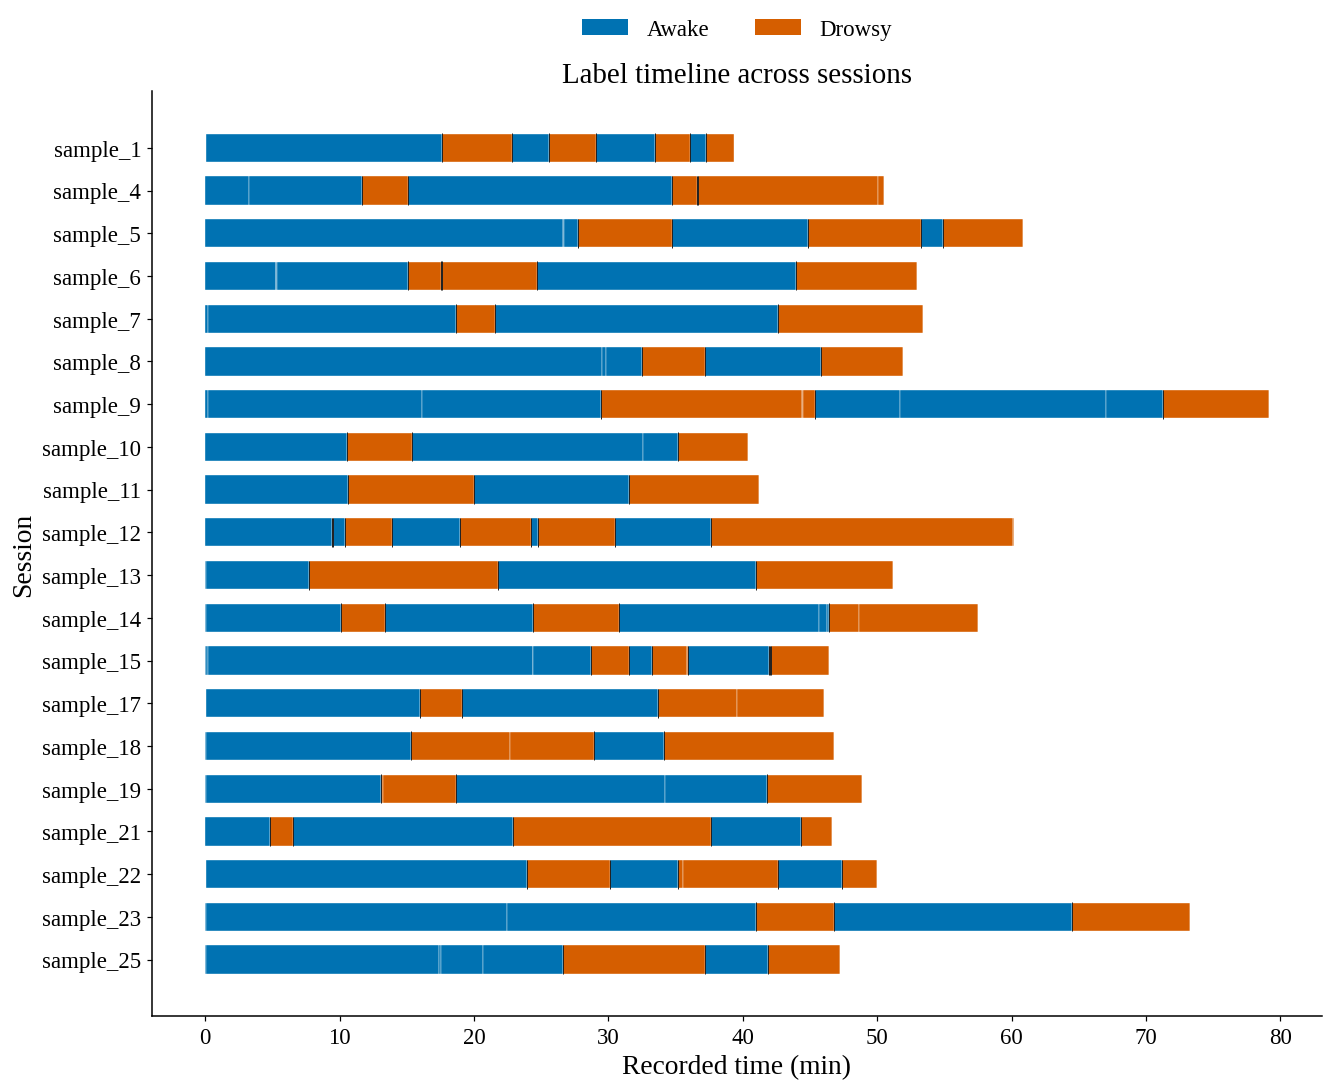

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.


findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


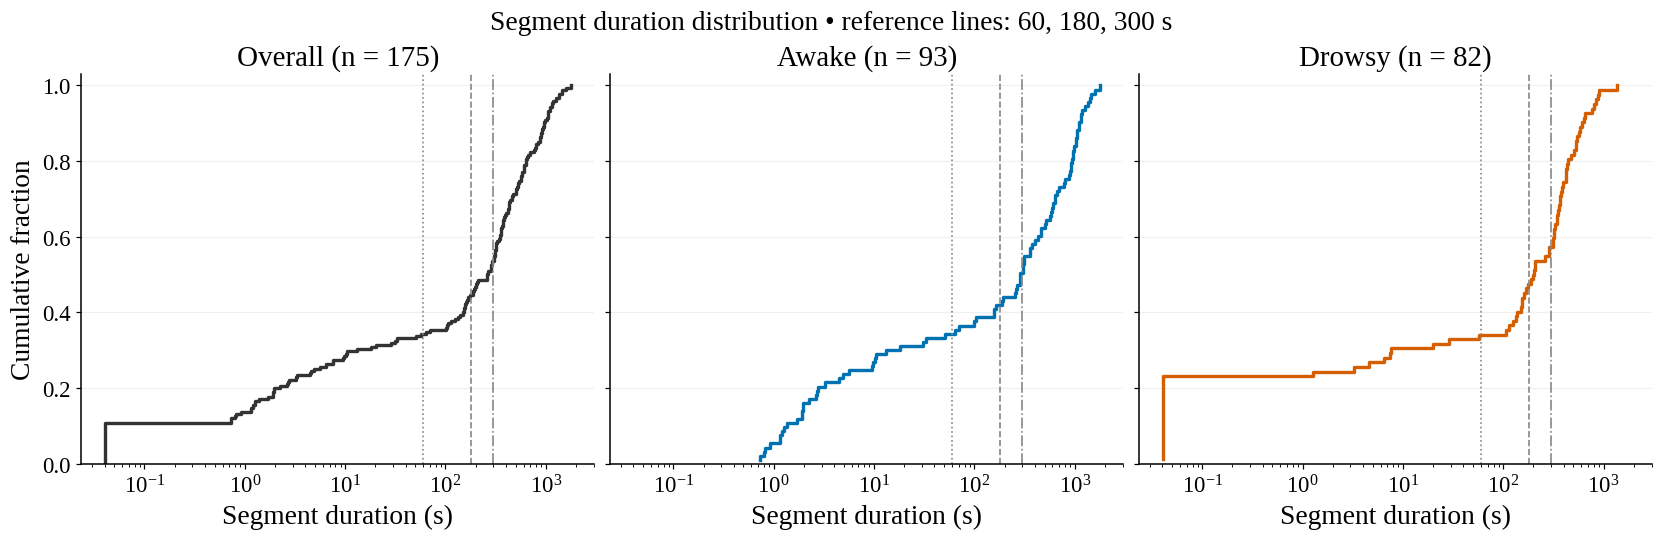

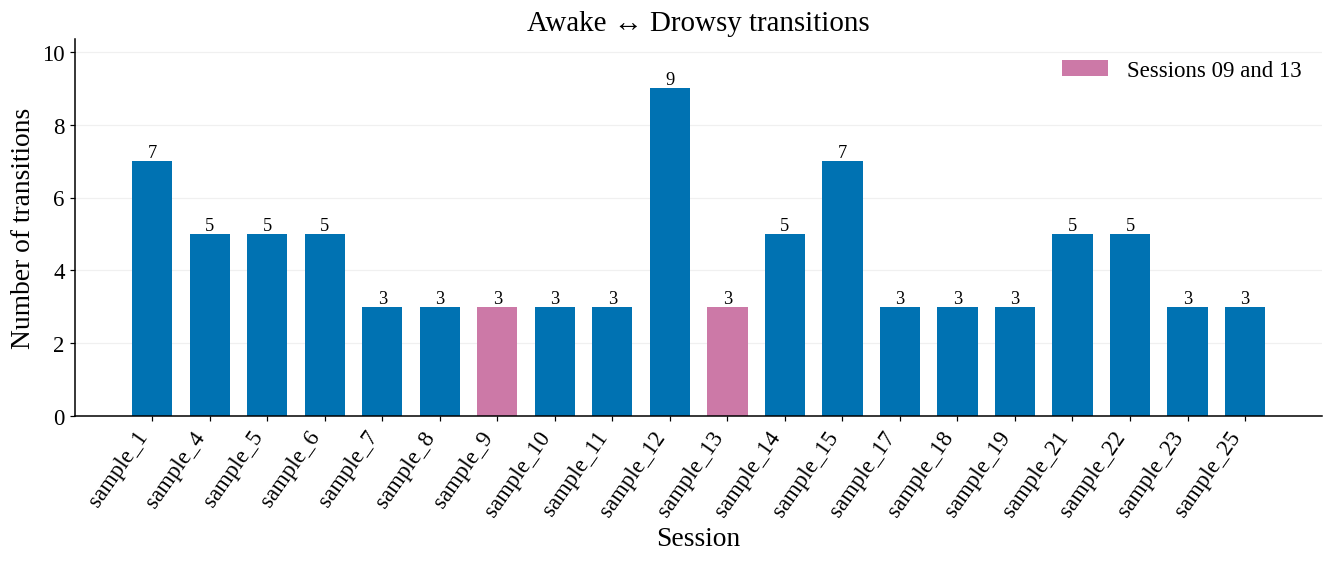

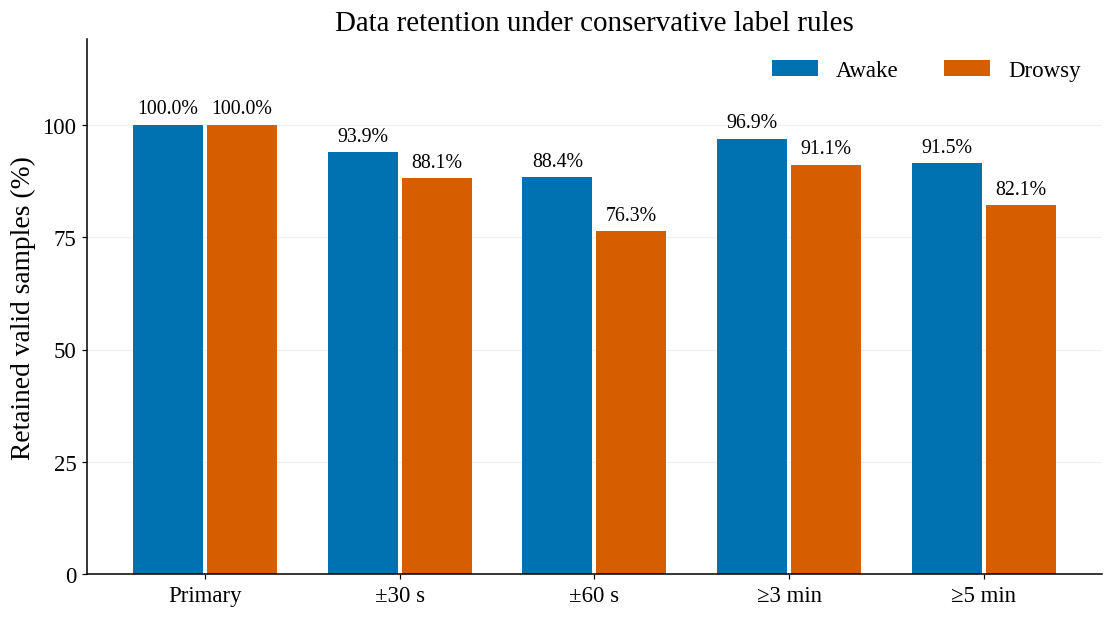

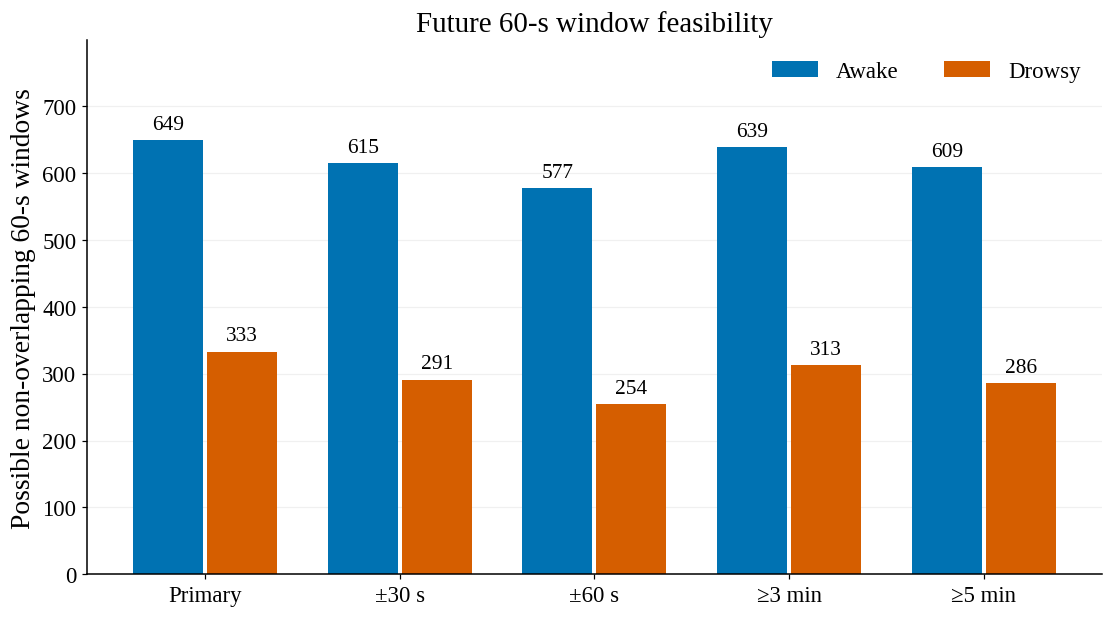

In [10]:
figures = publication_figures(tables, font_family=FONT_FAMILY,
                              font_paths=FONT_PATHS, dpi=FIGURE_DPI)
for figure in figures:
    display(figure)
    plt.close(figure)


# Verification Phase A — Độ tin cậy của dữ liệu và nhãn

## Mục tiêu

Dữ liệu được thu bằng cảm biến PPG giá rẻ và nhãn Awake/Drowsy dựa trên KSS chủ quan.

Phase A nhằm kiểm tra:

> Dataset có đủ ổn định về cấu trúc và nhãn để sử dụng cho phân tích khoa học tiếp theo hay không.

Phase này không nhằm chứng minh nhãn là ground truth tuyệt đối.

---

## 1. Kiểm tra tính toàn vẹn dữ liệu

Kết quả:

- 20/20 session đạt kiểm tra cấu trúc.
- Không có timestamp trùng.
- Không có nhãn thiếu hoặc sai mapping.
- Không có NaN/Inf trong tín hiệu raw và processed.
- Các gap thời gian đều rất nhỏ, lớn nhất < 0.2 s.

Ý nghĩa:

> Không phát hiện lỗi kỹ thuật nghiêm trọng có khả năng làm sai lệch toàn bộ phân tích tiếp theo.

---

## 2. Kiểm tra cấu trúc nhãn

Toàn bộ dataset có:

- 175 đoạn trạng thái liên tục.
- 93 đoạn Awake.
- 82 đoạn Drowsy.
- 86 lần chuyển Awake ↔ Drowsy.

Một số đoạn khá ngắn, cho thấy nhãn có mức độ phân mảnh nhất định.

Ý nghĩa:

> Nhãn không hoàn toàn ổn định theo thời gian, nhưng mức độ phân mảnh đã được định lượng và có thể kiểm tra bằng các phân tích độ nhạy bảo thủ hơn.

---

## 3. Các điều kiện kiểm tra độ nhạy

### P0 — Dữ liệu chính

Giữ toàn bộ dữ liệu hợp lệ theo nhãn hiện tại.

Mục đích:

> Là mốc tham chiếu để so sánh với các điều kiện bảo thủ hơn.

### T30 — Loại ±30 s quanh điểm chuyển trạng thái

Loại dữ liệu nằm trong 30 giây trước và sau mỗi lần Awake ↔ Drowsy.

Lý do:

> Vùng gần điểm chuyển trạng thái có thể chứa trạng thái sinh lý pha trộn hoặc nhãn kém chắc chắn hơn.

T30 vẫn giữ:

- khoảng 94% dữ liệu Awake
- khoảng 88% dữ liệu Drowsy
- đủ 20/20 session ghép cặp

### T60 — Loại ±60 s quanh điểm chuyển trạng thái

Là phiên bản bảo thủ hơn T30.

T60 vẫn giữ:

- khoảng 88% dữ liệu Awake
- khoảng 76% dữ liệu Drowsy
- đủ 20/20 session ghép cặp

Ý nghĩa:

> Nếu kết quả chính vẫn giữ ở T30 và T60, có thể lập luận rằng chúng không phụ thuộc chủ yếu vào dữ liệu nằm sát vùng chuyển trạng thái.

### S3 — Chỉ giữ đoạn trạng thái dài ít nhất 3 phút

Mục đích:

> Loại các đoạn Awake/Drowsy rất ngắn, có khả năng phản ánh trạng thái chưa ổn định.

S3 vẫn giữ:

- khoảng 97% Awake
- khoảng 91% Drowsy
- 20/20 session ghép cặp

### S5 — Chỉ giữ đoạn trạng thái dài ít nhất 5 phút

Là kiểm tra nghiêm ngặt hơn S3.

S5 vẫn giữ:

- khoảng 92% Awake
- khoảng 82% Drowsy
- 19/20 session ghép cặp

Ý nghĩa:

> Nếu kết quả vẫn giữ ở S3 và S5, chúng cũng tồn tại khi chỉ dùng các trạng thái kéo dài và ổn định hơn.

---

## 4. Session 09 và 13

Hai session này trước đây có hướng thay đổi NTSA ngược với xu hướng chung.

Phase A không phát hiện bằng chứng rõ rằng chúng có nhãn bất thường hơn các session khác.

Ý nghĩa:

> Chưa có cơ sở để loại session 09 hoặc 13 vì vấn đề chất lượng nhãn.

---

## 5. Kết luận Phase A

Phase A cho thấy:

> Dataset processed có cấu trúc thời gian, tín hiệu và nhãn ổn định, không có lỗi kỹ thuật nghiêm trọng, và vẫn giữ đủ dữ liệu khi áp dụng các cách chọn nhãn bảo thủ hơn.

Các điều kiện được giữ lại cho bước kiểm tra NTSA tiếp theo:

```text
P0  = dữ liệu chính
T30 = loại ±30 s quanh chuyển trạng thái
T60 = loại ±60 s quanh chuyển trạng thái
S3  = chỉ giữ đoạn ≥3 phút
S5  = chỉ giữ đoạn ≥5 phút


# Lập luận về độ tin cậy của nhãn trước bước verification cuối

## Vấn đề

Nhãn Awake/Drowsy được xây dựng từ KSS chủ quan, vì vậy không thể xem là ground truth tuyệt đối.

Tuy nhiên, mục tiêu của verification không phải chứng minh nhãn hoàn hảo, mà là kiểm tra xem:

> Phần lớn dữ liệu có nằm trong các trạng thái đủ ổn định để sử dụng cho phân tích khoa học hay không, và các kết luận sau này có còn giữ khi loại bỏ những vùng nhãn kém chắc chắn hơn hay không.

---

## Bằng chứng hiện có

### 1. Nhãn không có lỗi cấu trúc

Trên 20 session:

- 0 nhãn thiếu
- 0 nhãn ngoài mapping
- toàn bộ timeline nhãn được tái dựng đầy đủ

Điều này cho thấy không có lỗi annotation mang tính kỹ thuật hoặc dữ liệu nhãn bị hỏng.

---

### 2. Phần lớn thời lượng dữ liệu nằm trong các đoạn trạng thái đủ dài

Dataset có 175 đoạn trạng thái liên tục, với trung vị thời lượng khoảng:

```text
260 s ≈ 4.3 phút
````

Mặc dù có các đoạn ngắn và hiện tượng phân mảnh nhãn, phần lớn thời lượng vẫn nằm trong các đoạn dài hơn.

Bằng chứng rõ nhất là:

```text
S3: chỉ giữ segment ≥3 phút
→ giữ ~97% Awake
→ giữ ~91% Drowsy
→ vẫn đủ 20/20 session ghép cặp
```

Ngay cả khi nghiêm ngặt hơn:

```text
S5: chỉ giữ segment ≥5 phút
→ giữ ~92% Awake
→ giữ ~82% Drowsy
→ vẫn còn 19/20 session ghép cặp
```

Ý nghĩa:

> Các đoạn trạng thái ngắn tồn tại, nhưng chúng không chi phối phần lớn dataset.

---

### 3. Phần lớn dữ liệu cũng không nằm sát vùng chuyển trạng thái

Khi loại các vùng có khả năng bất định cao hơn quanh Awake↔Drowsy transition:

```text
T30: loại ±30 s
→ giữ ~94% Awake
→ giữ ~88% Drowsy
→ 20/20 session ghép cặp
```

```text
T60: loại ±60 s
→ giữ ~88% Awake
→ giữ ~76% Drowsy
→ 20/20 session ghép cặp
```

Ý nghĩa:

> Dataset không phụ thuộc chủ yếu vào dữ liệu nằm sát ranh giới chuyển trạng thái.

---

## Cách diễn giải phù hợp

Không nên nói:

> Nhãn KSS rất ổn định hoặc hoàn toàn chính xác.

Nên nói:

> Nhãn có một mức độ phân mảnh nhất định, nhưng phần lớn thời lượng dữ liệu vẫn nằm trong các đoạn trạng thái kéo dài và nằm ngoài vùng chuyển tiếp. Các tập dữ liệu bảo thủ hơn vẫn giữ phần lớn dữ liệu và gần như toàn bộ cấu trúc ghép cặp Awake–Drowsy.

Điều này cho thấy:

> Dataset đủ phù hợp để tiếp tục phân tích khoa học, với điều kiện các finding chính vẫn được kiểm tra dưới các tập nhãn bảo thủ hơn.

---

## Ý nghĩa cho bước verification cuối

Các điều kiện đã được freeze:

```text
P0  = toàn bộ dữ liệu hợp lệ
T30 = loại ±30 s quanh transition
T60 = loại ±60 s quanh transition
S3  = chỉ giữ segment ≥3 phút
S5  = chỉ giữ segment ≥5 phút
```

Bước tiếp theo sẽ kiểm tra xem các finding NTSA chính có còn giữ dưới các điều kiện này hay không.

Nếu hướng và độ lớn hiệu ứng vẫn ổn định, có thể lập luận rằng:

> Kết luận khoa học không phụ thuộc mạnh vào các vùng nhãn có khả năng bất định cao hơn, dù nhãn được xây dựng từ KSS chủ quan.

```
